In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sonardataset.csv")

In [3]:
import os
print(os.listdir())

['.config', 'sonardataset.csv', 'sample_data']


In [4]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [5]:
df.shape

(208, 61)

In [6]:
df.columns

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19',
       'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28',
       'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37',
       'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46',
       'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55',
       'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
x_1,0
x_2,0
x_3,0
x_4,0
x_5,0
...,...
x_57,0
x_58,0
x_59,0
x_60,0


In [9]:
df['Y'].value_counts()

,count
Y,
M,111
R,97


In [10]:
X = df.drop('Y', axis=1)

y = df['Y']

print(X.shape)
print(y.shape)

(208, 60)
(208,)


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(np.unique(y))

[0 1]


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X.shape)

(208, 60)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(166, 60)
(42, 60)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_model = Sequential()

ann_model.add(
    Dense(
        32,
        activation='relu',
        input_shape=(60,)
    )
)

ann_model.add(
    Dense(
        16,
        activation='relu'
    )
)

ann_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = ann_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.5758 - loss: 0.8035 - val_accuracy: 0.3529 - val_loss: 1.0024
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5606 - loss: 0.6811 - val_accuracy: 0.3529 - val_loss: 0.8417
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6288 - loss: 0.6173 - val_accuracy: 0.5294 - val_loss: 0.7330
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7045 - loss: 0.5664 - val_accuracy: 0.6176 - val_loss: 0.6745
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.5283 - val_accuracy: 0.6765 - val_loss: 0.6388
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8258 - loss: 0.4989 - val_accuracy: 0.6765 - val_loss: 0.6099
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8485 - loss: 0.4700 - val_accuracy: 0.7059 - val_loss: 0.5836
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8485 - loss: 0.4428 - val_accuracy: 0.7059 - val_loss: 

In [16]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [17]:
print("Final Training Accuracy :", history.history['accuracy'][-1])

print("Final Validation Accuracy :", history.history['val_accuracy'][-1])

print("Final Training Loss :", history.history['loss'][-1])

print("Final Validation Loss :", history.history['val_loss'][-1])

Final Training Accuracy : 1.0
Final Validation Accuracy : 0.8529411554336548
Final Training Loss : 0.003947448916733265
Final Validation Loss : 0.693564772605896


In [18]:
y_pred_prob = ann_model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

y_pred = y_pred.flatten()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8095238095238095
Precision: 0.9285714285714286
Recall   : 0.65
F1 Score : 0.7647058823529411


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21  1]
 [ 7 13]]


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.95      0.84        22
           1       0.93      0.65      0.76        20

    accuracy                           0.81        42
   macro avg       0.84      0.80      0.80        42
weighted avg       0.84      0.81      0.80        42



In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

tuned_model = Sequential()

tuned_model.add(Dense(64, activation='relu', input_shape=(60,)))
tuned_model.add(Dense(32, activation='relu'))
tuned_model.add(Dense(16, activation='relu'))
tuned_model.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

tuned_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tuned_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_tuned = tuned_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.6212 - loss: 0.6438 - val_accuracy: 0.7059 - val_loss: 0.6399
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8182 - loss: 0.5353 - val_accuracy: 0.7647 - val_loss: 0.5835
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8788 - loss: 0.4479 - val_accuracy: 0.7647 - val_loss: 0.4997
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8864 - loss: 0.3729 - val_accuracy: 0.7941 - val_loss: 0.4513
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9318 - loss: 0.3020 - val_accuracy: 0.8235 - val_loss: 0.4042
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9545 - loss: 0.2410 - val_accuracy: 0.8529 - val_loss: 0.3898
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9773 - loss: 0.1873 - val_accuracy: 0.8529 - val_loss: 0.3837
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9924 - loss: 0.1463 - val_accuracy: 0.8

In [24]:
y_pred_prob_tuned = tuned_model.predict(X_test)

y_pred_tuned = (y_pred_prob_tuned > 0.5).astype(int)

y_pred_tuned = y_pred_tuned.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step


In [25]:
acc_tuned = accuracy_score(y_test, y_pred_tuned)

prec_tuned = precision_score(y_test, y_pred_tuned)

rec_tuned = recall_score(y_test, y_pred_tuned)

f1_tuned = f1_score(y_test, y_pred_tuned)

print("Accuracy :", acc_tuned)
print("Precision:", prec_tuned)
print("Recall   :", rec_tuned)
print("F1 Score :", f1_tuned)

Accuracy : 0.8809523809523809
Precision: 0.9411764705882353
Recall   : 0.8
F1 Score : 0.8648648648648649


In [26]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Default ANN":[
        accuracy,
        precision,
        recall,
        f1
    ],

    "Tuned ANN":[
        acc_tuned,
        prec_tuned,
        rec_tuned,
        f1_tuned
    ]

})

comparison

,Metric,Default ANN,Tuned ANN
0,Accuracy,0.809524,0.880952
1,Precision,0.928571,0.941176
2,Recall,0.650000,0.800000
3,F1 Score,0.764706,0.864865


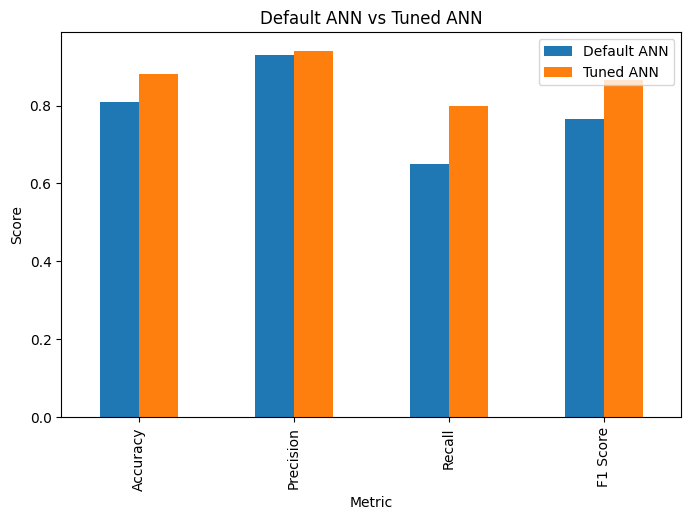

In [27]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default ANN vs Tuned ANN")

plt.ylabel("Score")

plt.show()